## Segmentation test

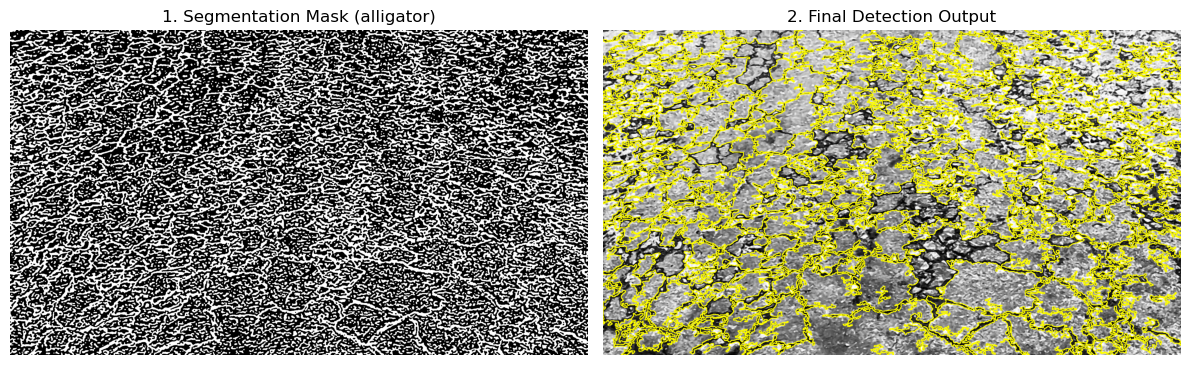

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# function for detection and segmentation 
def apply_detection(enhanced_img, detection_frame, mode):
    # Initialize the mask variable with nothing (None) so it can be used later
    mask = None
    # Set a default color (Red) to ensure the code has a color to use even if the mode is not recognized
    color = (0, 0, 255) 

    # A small 3x3 square matrix used to remove tiny noise or dots from the image
    small_kernel = np.ones((3, 3), np.uint8)
    # A larger 7x7 elliptical shape used to bridge gaps and smooth the detected crack areas
    large_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    if mode == "pothole":
        _, thresh = cv2.threshold(enhanced_img, 60, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        mask = cv2.erode(cv2.dilate(closing, large_kernel, iterations=1), small_kernel, iterations=1)
        color = (0, 0, 255)
    elif mode == "alligator":
        thresh = cv2.adaptiveThreshold(enhanced_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)
        clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3)))
        mask = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, np.ones((3,3)))
        color = (0, 255, 255)
    elif mode == "raveling":
        _, thresh = cv2.threshold(enhanced_img, 60, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        mask = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        color = (0, 255, 255)
    elif mode == "edge":
        _, thresh = cv2.threshold(enhanced_img, 80, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        mask = cv2.erode(cv2.dilate(closing, large_kernel, iterations=1), small_kernel, iterations=1)
        color = (0, 255, 255)

    # Create a copy of the original image to draw detections on, without changing the original frame
    # 'contours' holds the crack shapes; the '_' just ignores extra details we don't need
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Loop through each detected crack outline one by one
    for crack in contours:
        # Calculate the size (area) of the current crack in pixels
        area = cv2.contourArea(crack)
        # Set a minimum size limit to ignore unimportant dots (noise)
        min_area = 3000 if mode == "pothole" else 500 

        # Skip small dots and only keep the big cracks
        if area > min_area:
            # For these specific cracks, draw the exact outline (shape)
            if mode in ["alligator", "raveling", "edge"]:
                # -1 means draw all contours in the provided list
                cv2.drawContours(detection_frame, [crack], -1, color, 2)
            # For other modes (like potholes) draw a simple rectangle box around it
            else:
                # Get the coordinates and size (x, y, width, height) to fit a box around the crack
                x, y, w, h = cv2.boundingRect(crack)
                # Draw the actual rectangle box on the image using those coordinates
                cv2.rectangle(detection_frame, (x, y), (x + w, y + h), color, 2)

    return mask, detection_frame

# Main Process
input_path = "Enhanced_frames/frame_16_enhanced.png" 
# change the crack type (alligator, pothole, raveling, edge)
MODE = "alligator"

enhanced_img = cv2.imread(input_path, 0)


if enhanced_img is None:
    print("Error: cannot open the image")
else:

    # Create a copy for draw boundaries 
    detection_result = cv2.cvtColor(enhanced_img, cv2.COLOR_GRAY2BGR)
    
    # function for detection and segmentation: Detect cracks/potholes and get the black and white mask and the final drawn frame
    mask, result = apply_detection(enhanced_img, detection_result, MODE)

    
    # DISPLAY RESULTS
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f"1. Segmentation Mask ({MODE})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Convert BGR to RGB for correct colors in Matplotlib
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("2. Final Detection Output")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()